# Example of how to use the adaptive decomposition

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Rectangle
from pathlib import Path

from adapt_decomp.utils import load_example
from adapt_decomp.utils.plots import plot_sep_vectors_diff, plot_whitening_comp, plot_sep_vectors_comp, plot_sources
from adapt_decomp.adaptation import AdaptDecomp, AdaptConfig
from adapt_decomp.adaptation.io import load_output
from adapt_decomp.spikes import rate_of_agreement, rate_of_agreement_paired

%load_ext autoreload
%autoreload 2

sns.set_theme(style='whitegrid', font_scale=1.1)

## 1. Input data
This notebook applies the decomposition adaptation to a wrist dynamic contraction simulated with [NeuroMotion](https://github.com/shihan-ma/NeuroMotion). The EMG signals were simulated from the forearm (band of 10 rows and 32 columns) during an index flexion (FDS muscle activated at 15% MVC) while the wrist flexed from 0 degrees to -40 degrees in a staircase pattern (30 s plateaus, 10 s ramps at 1deg/s). The first plateau is used to precalibrate a convolutive blind source separation model that is adapted for the rest of the contraction.

Load the simulated dataset and the corresponding decomposition during the calibration segment.

In [2]:
# Load data
path_emg = Path('..', '..', 'data', 'JNE_data', 'sim', 'data_sim.hdf5')
path_decomp = Path('..', '..', 'data', 'JNE_data', 'sim', 'decomp_sim.mat')

data = load_example(path_emg, path_decomp, False)
print(data.keys())

cbss_result = data['cbss_result']
cbss_config = data['cbss_config']
units = cbss_result.spikes_centr.shape[0]

dict_keys(['cbss_result', 'cbss_config', 'emg', 'gt_full_bin', 'roa_calib', 'preprocess', 'fs', 'timestamps', 'angle_profile', 'force_profile', 'ch_map'])


Take a look at the data

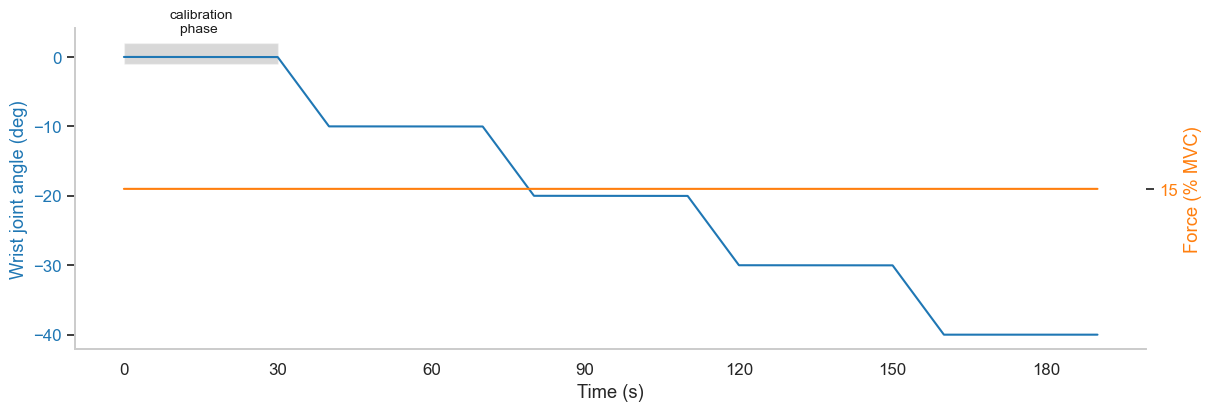

In [3]:
fig, axs = plt.subplots(1,1, figsize=(12,4), layout='constrained')

axs.add_patch( Rectangle((0,-1), 30, 3, facecolor='grey', edgecolor=None, alpha=0.3) )
axs.text(15, 5, 'calibration\nphase ', dict(ha='center', va='center', fontsize=10, color='k'))
axs.plot(data['timestamps'], data['angle_profile'], color='tab:blue')
axs.tick_params(axis='y', labelcolor='tab:blue')
axs.set_ylabel('Wrist joint angle (deg)', color='tab:blue')
axs.set_xlabel('Time (s)')
axs.grid(False)
axs.spines['top'].set_visible(False)
axs.spines['right'].set_visible(False)

axs1 = axs.twinx()
axs1.plot(data['timestamps'], data['force_profile'], color='tab:orange')
axs1.tick_params(axis='y', labelcolor='tab:orange')
axs1.set_ylabel('Force (% MVC)', color='tab:orange')
axs1.spines['top'].set_visible(False)
axs1.spines['right'].set_visible(False)
axs1.set(xticks=range(0,191,30), yticks=[15])
axs1.grid(False)

plt.show()

## 2. Decomposition comparison for online execution

For real-time applications the computation of the loss can be avoided and the saving of the adapted parameters can be switched off for maximum efficiency. The loss is only needed to optimise the hyperparameters of the decomposition (whitening and separation vectors learning rate), but it is not used during the adaptation. This settings can be modified for more in depth analysis as it is shown in the next section.

### 2.1. Without adaptation

In [4]:
# Config -- configs/adapt_configs/default_fixed.yaml has every adaptation flag off
# (adapt_wh/sv/sd=False), i.e. run the fixed calibration model without updating it.
config_no_adapt = AdaptConfig.from_yaml('../../configs/adapt_configs/default_fixed.yaml')
config_no_adapt.compute_loss = False  # False for faster execution, True for loss logging
config_no_adapt.device = 'cpu'
config_no_adapt.ext_fact = cbss_result.ext_fact  # match this calibration's own ext_fact

# Build the model from the calibration and run it
dyndec_no_adapt = AdaptDecomp.from_calibration(
    calibration=cbss_result, cbss_config=cbss_config, adapt_config=config_no_adapt,
)
outputs_no_adapt = dyndec_no_adapt.process_data(data['emg'], preprocess=data['preprocess'])

print('Decomposition without adaptation done!')

Decomposition without adaptation done!


### 2.2 With adaptation

In [5]:
# Config -- configs/adapt_configs/default_neuromotion.yaml is tuned for exactly this
# NeuroMotion-simulated dataset (wh_learning_rate/sv_learning_rate, lr_mode='fixed').
config_adapt = AdaptConfig.from_yaml('../../configs/adapt_configs/default_neuromotion.yaml')
config_adapt.compute_loss = False  # False for faster execution, True for loss logging
config_adapt.device = 'cpu'
config_adapt.ext_fact = cbss_result.ext_fact  # match this calibration's own ext_fact

dyndec_adapt = AdaptDecomp.from_calibration(
    calibration=cbss_result, cbss_config=cbss_config, adapt_config=config_adapt,
)
outputs_adapt = dyndec_adapt.process_data(data['emg'], preprocess=data['preprocess'])

print('Decomposition with adaptation done!')

Decomposition with adaptation done!


### 2.3. Evaluate execution time per batch and method

In [6]:
# CPU without loss calculaion
title = 'No adaptation'
print(title + '\n' + '-'*len(title))
for key in ['preprocess_time_ms', 'wh_time_ms', 'sv_time_ms', 'sd_time_ms', 'total_time_ms']:
    print(f'{key:>19}: {outputs_no_adapt[key].mean():.3f} ± {outputs_no_adapt[key].std():.3f} ms')

title = 'Adaptation'
print('\n' + title + '\n' + '-'*len(title))
for key in ['preprocess_time_ms', 'wh_time_ms', 'sv_time_ms', 'sd_time_ms', 'total_time_ms']:
    print(f'{key:>19}: {outputs_adapt[key].mean():.3f} ± {outputs_adapt[key].std():.3f} ms')

No adaptation
-------------
 preprocess_time_ms: 0.000 ± 0.000 ms
         wh_time_ms: 0.527 ± 1.090 ms
         sv_time_ms: 0.086 ± 0.304 ms
         sd_time_ms: 0.588 ± 0.976 ms
      total_time_ms: 1.201 ± 1.434 ms

Adaptation
----------
 preprocess_time_ms: 0.000 ± 0.000 ms
         wh_time_ms: 13.671 ± 4.261 ms
         sv_time_ms: 0.923 ± 1.728 ms
         sd_time_ms: 1.476 ± 1.852 ms
      total_time_ms: 16.070 ± 4.623 ms


## 3. Decomposition comparison for offline execution

Here the loss is computed for further decomposition validation. Note that the loss can always be reconstructed from data after being recorded and adapted. In this section, the adapted parameters per batch are also stored.

### 3.1. Without adaptation (loss computation)

In [7]:
# default_fixed.yaml already has compute_loss=True -- only the device needs overriding.
config_no_adapt = AdaptConfig.from_yaml('../../configs/adapt_configs/default_fixed.yaml')
config_no_adapt.device = 'cpu'
config_no_adapt.ext_fact = cbss_result.ext_fact  # match this calibration's own ext_fact

dyndec_no_adapt = AdaptDecomp.from_calibration(
    calibration=cbss_result, cbss_config=cbss_config, adapt_config=config_no_adapt,
)
outputs_no_adapt = dyndec_no_adapt.process_data(data['emg'], preprocess=data['preprocess'])

print('Decomposition without adaptation done!')

Decomposition without adaptation done!


### 3.2 With adaptation (loss computation + parameter saving)

In [8]:
# save_params=True writes whitening/sep_vectors/base_centr/spikes_centr every batch to save_path.
path_out_adapt = Path('..', '..', 'data', 'JNE_data', 'sim', 'decomp_adapt_out.hdf5') # Rename file to avoid overwriting the previous run's output.

config_adapt = AdaptConfig.from_yaml('../../configs/adapt_configs/default_neuromotion.yaml')
config_adapt.device = 'cpu'
config_adapt.ext_fact = cbss_result.ext_fact  # match this calibration's own ext_fact
config_adapt.save_params = True

dyndec_adapt = AdaptDecomp.from_calibration(
    calibration=cbss_result, cbss_config=cbss_config, adapt_config=config_adapt,
    save_path=path_out_adapt,
)
outputs_adapt = dyndec_adapt.process_data(data['emg'], preprocess=data['preprocess'])

print('Decomposition with adaptation done!')

Decomposition with adaptation done!


### 3.3. Evaluate execution time per batch and method

In [9]:
# CPU with loss calculaion
title = 'No adaptation'
print(title + '\n' + '-'*len(title))
for key in ['preprocess_time_ms', 'wh_time_ms', 'sv_time_ms', 'sd_time_ms', 'total_time_ms']:
    print(f'{key:>19}: {outputs_no_adapt[key].mean():.3f} ± {outputs_no_adapt[key].std():.3f} ms')

title = 'Adaptation'
print('\n' + title + '\n' + '-'*len(title))
for key in ['preprocess_time_ms', 'wh_time_ms', 'sv_time_ms', 'sd_time_ms', 'total_time_ms']:
    print(f'{key:>19}: {outputs_adapt[key].mean():.3f} ± {outputs_adapt[key].std():.3f} ms')

No adaptation
-------------
 preprocess_time_ms: 0.000 ± 0.000 ms
         wh_time_ms: 10.998 ± 2.365 ms
         sv_time_ms: 0.114 ± 0.429 ms
         sd_time_ms: 0.647 ± 0.974 ms
      total_time_ms: 11.758 ± 2.406 ms

Adaptation
----------
 preprocess_time_ms: 0.000 ± 0.000 ms
         wh_time_ms: 13.814 ± 3.726 ms
         sv_time_ms: 0.868 ± 1.777 ms
         sd_time_ms: 1.307 ± 1.855 ms
      total_time_ms: 15.989 ± 4.101 ms


### 3.4. Analyse saved parameters

In [10]:
# Load data
path_out_adapt = Path('..', '..', 'data', 'JNE_data', 'sim', 'decomp_adapt_out.hdf5')
params_adapt = load_output(path_out_adapt)
print(params_adapt.keys())

dict_keys(['base_centr', 'ipts', 'preprocess_time_ms', 'sd_time_ms', 'sep_vectors', 'spikes', 'spikes_centr', 'sv_loss', 'sv_loss_total', 'sv_time_ms', 'total_loss', 'total_time_ms', 'wh_loss', 'wh_loss_total', 'wh_time_ms', 'wh_trace', 'whitening'])


In [11]:
keys = ['whitening', 'sep_vectors', 'base_centr', 'spikes_centr', 'wh_loss', 'sv_loss']
for key in keys:
    print(f'{key:<13}: {params_adapt[key].shape}')

whitening    : (1908, 960, 960)
sep_vectors  : (1908, 18, 960)
base_centr   : (1908, 18)
spikes_centr : (1908, 18)
wh_loss      : (1908,)
sv_loss      : (1908, 18)


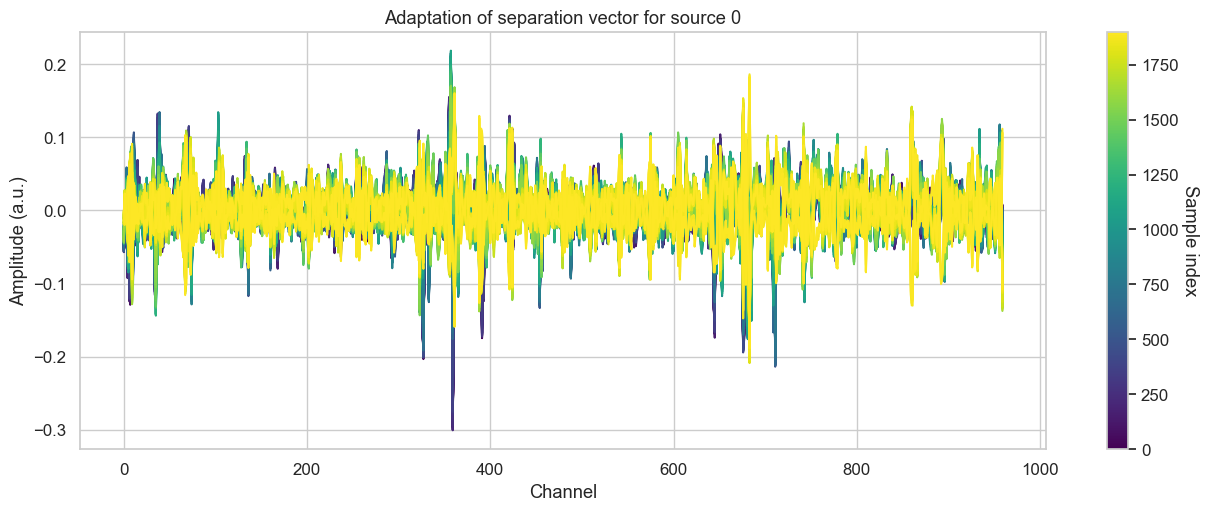

In [12]:
# Plot changes in separation vectors
source = 0  # Select source to plot
samples = np.arange(0, params_adapt['sep_vectors'].shape[0], 10)

# Colour map
cmap = plt.get_cmap('viridis')
norm = plt.Normalize(vmin=samples.min(), vmax=samples.max())

fig, axs = plt.subplots(1,1, figsize=(12,5), layout='constrained')
for s in samples:
    sv = params_adapt['sep_vectors'][s,source]
    axs.plot(sv, color=cmap(norm(s)), label=f'Sample {s}')
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=axs)
cbar.set_label('Sample index', rotation=270, labelpad=15)
axs.set_title(f'Adaptation of separation vector for source {source}')
axs.set_xlabel('Channel')
axs.set_ylabel('Amplitude (a.u.)')
plt.show()

## 4. Evaluate the adaptation effect
To evaluate the effect of the adaptation we can take a look at the whitening and separation vector losses, defined as the median squared error between the Kulback-Leibler divergence of the whitened covariance during calibration and adaptation, and the median squared error between the contrast functions during the calibration and the adaptation, respectively.

Note how without adaptation the whitening loss increases following the same trend as the deviation in wrist joint angle, and how most of the spikes are lost after 10 degrees.

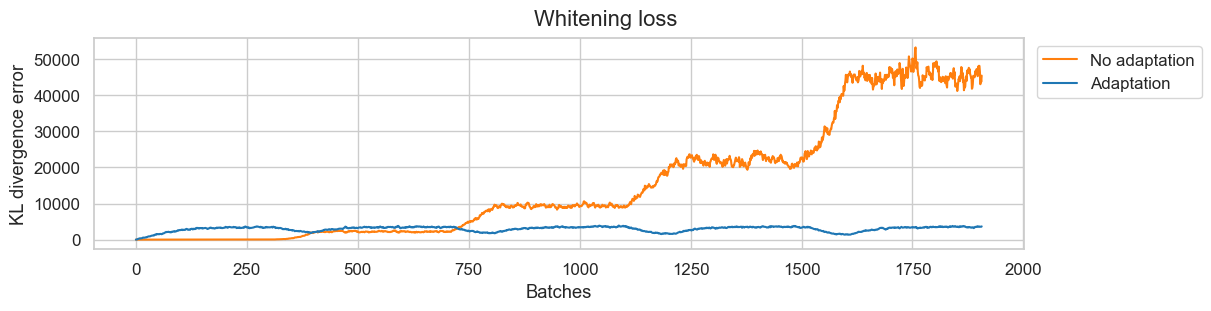

In [13]:
colors = ['tab:orange', 'tab:blue']

# Check the KL divergence error
fig, axs = plt.subplots(1, 1, figsize=(12, 3), layout='constrained')
axs.plot(outputs_no_adapt['wh_loss'][:-1], label='No adaptation', color=colors[0])
axs.plot(outputs_adapt['wh_loss'][:-1], label='Adaptation', color=colors[1])
axs.set(xlabel='Batches', ylabel='KL divergence error')
axs.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.suptitle('Whitening loss')
plt.show()

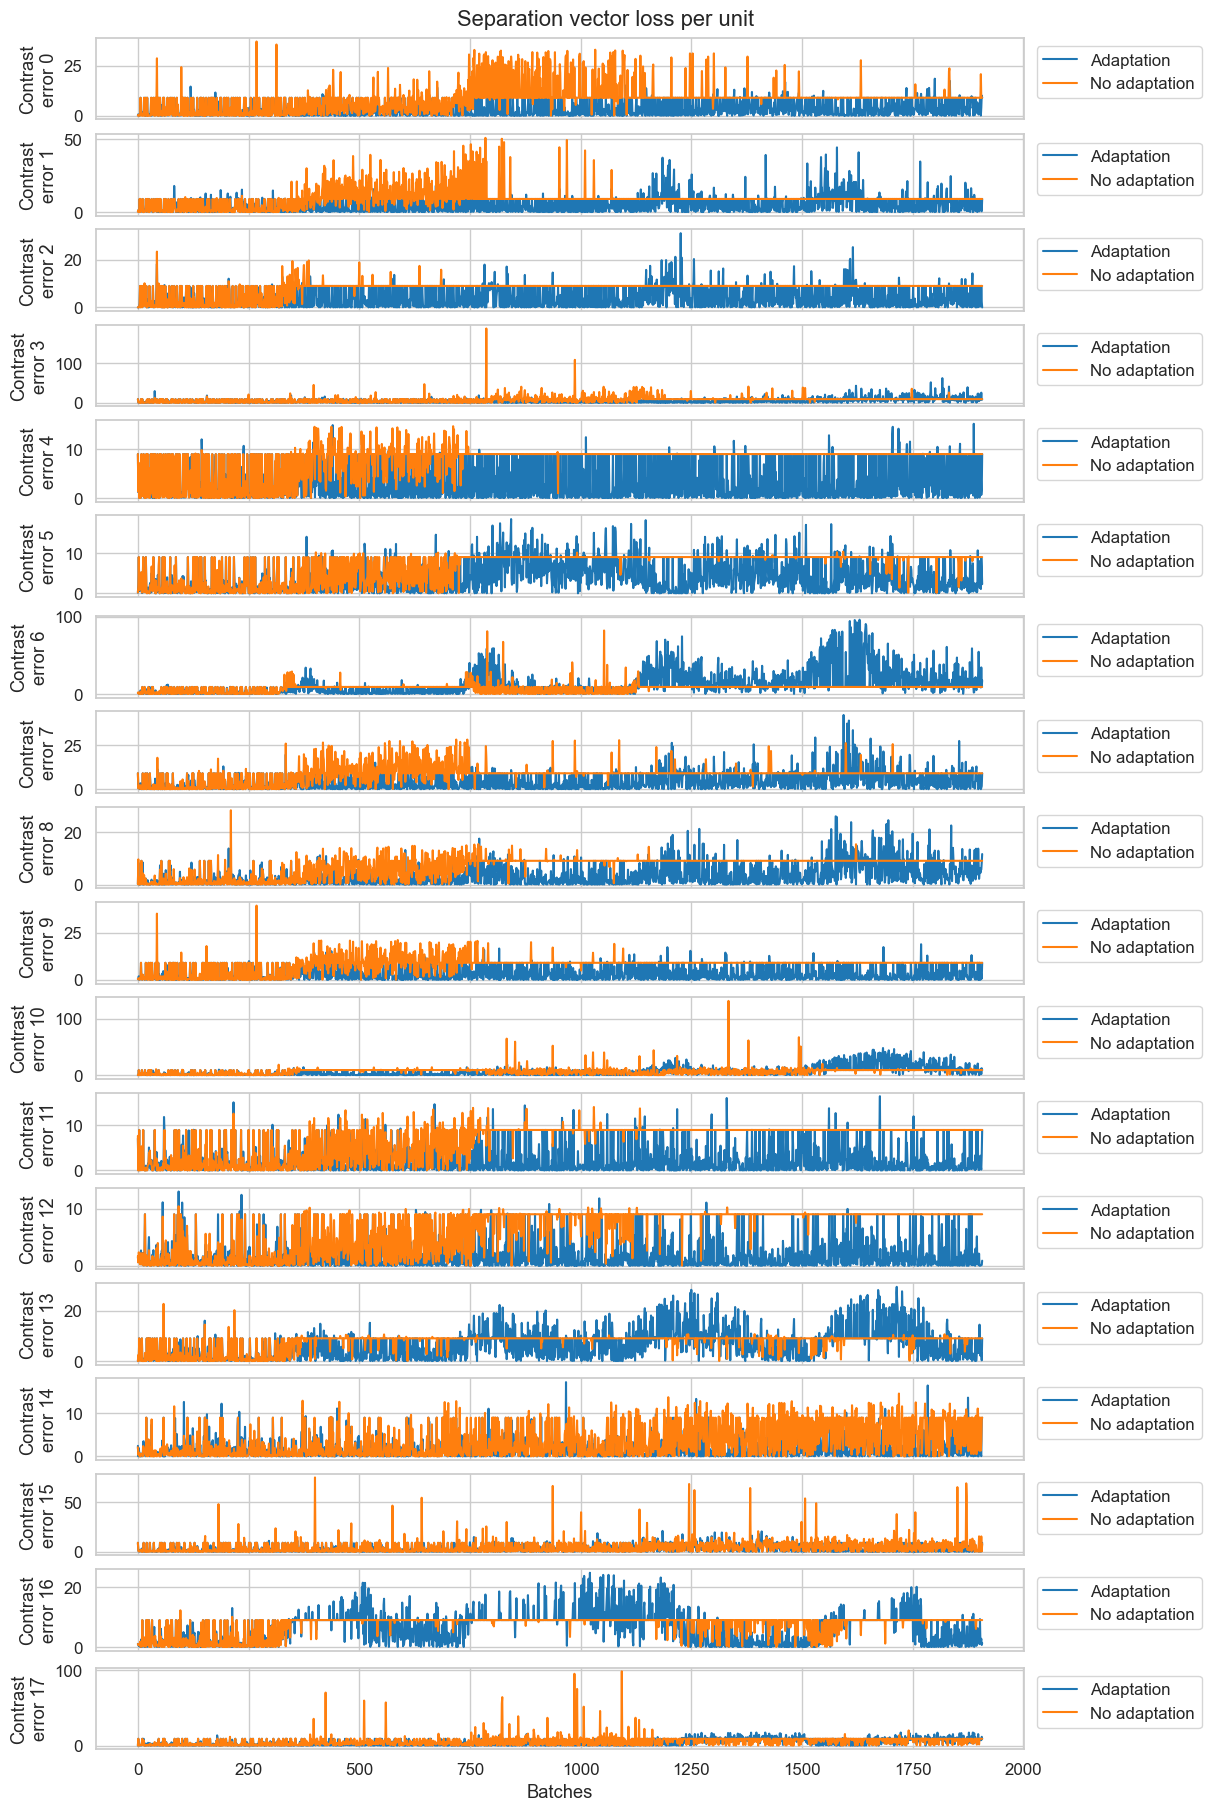

In [14]:
fig, axs = plt.subplots(units, 1, figsize=(12, units), layout='constrained', sharex=True)

for unit in range(units):
    axs[unit].plot(outputs_adapt['sv_loss'][:,unit], label='Adaptation', color=colors[1])
    axs[unit].plot(outputs_no_adapt['sv_loss'][:,unit], label='No adaptation', color=colors[0])
    axs[unit].set(ylabel=f'Contrast\nerror {unit}')
    axs[unit].legend(loc='upper right', bbox_to_anchor=(1.2, 1))

    if unit == units-1:
        axs[unit].set(xlabel='Batches')

plt.suptitle('Separation vector loss per unit')
plt.show()

## 5. Plot sources and spikes

Now let's plot the spike trains at the maximum angle deviation with and without adaptation. Notice how adaptation recovers almost all of the spikes that were lost with the change in joint angle.

In [ ]:
time_window = [180, 190]
idxs = np.arange(time_window[0]*2048, time_window[1]*2048).astype(int)

axs = plot_sources(
    sources={'Adaptation': outputs_adapt['sources'].numpy()[idxs] ** 2,
             'No adaptation': outputs_no_adapt['sources'].numpy()[idxs] ** 2},
    timestamps=data['timestamps'][idxs],
    spikes={'Adaptation': outputs_adapt['spikes'].numpy()[idxs],
            'No adaptation': outputs_no_adapt['spikes'].numpy()[idxs]},
)
plt.suptitle('Detected spikes')
plt.show()

## 6. Compute rate of agreement with ground truth
Since the dataset is simulated we can compute the rate of agreement between the ground truth and the detected spikes. `load_example()` already matched ground truth to `cbss_result`'s own units (`data['gt_full_bin']`) -- `AdaptDecomp` never reorders or discovers units, so this same pairing applies unchanged to `outputs_no_adapt`/`outputs_adapt`, and `rate_of_agreement_paired` (no re-matching) is what we want here. To match the detected to the simulated ones over calibration only we restrict to the first 30s.

In [16]:
# Compute rate of agreement over the calibration phase only
idxs = np.arange(0, 30 * 2048).astype(int)

roa_no_adapt, _, _ = rate_of_agreement_paired(data['gt_full_bin'][idxs], outputs_no_adapt['spikes'].numpy()[idxs], fs=data['fs'])
roa_adapt, _, _ = rate_of_agreement_paired(data['gt_full_bin'][idxs], outputs_adapt['spikes'].numpy()[idxs], fs=data['fs'])

print(f'Rate of agreement (no adaptation): {roa_no_adapt.mean()*100:.2f} ± {roa_no_adapt.std()*100:.2f} (med: {np.median(roa_no_adapt)*100:.2f}) %')
print(f'Rate of agreement (adaptation): {roa_adapt.mean()*100:.2f} ± {roa_adapt.std()*100:.2f} (med: {np.median(roa_adapt)*100:.2f}) %')

Rate of agreement (no adaptation): 99.40 ± 0.49 (med: 99.35) %
Rate of agreement (adaptation): 99.33 ± 0.50 (med: 99.27) %


Now let's compute the rate of agreement for the detected spikes over the whole recording.

Rate of agreement (no adaptation): 37.88 ± 18.23 (med: 37.29) %
Rate of agreement (adaptation): 89.97 ± 22.03 (med: 99.23) %


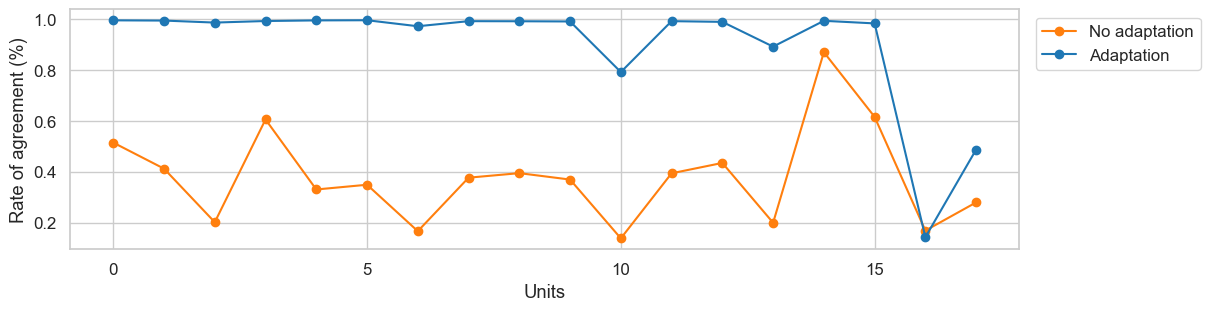

In [17]:
# Compute rate of agreement over the whole recording
roa_no_adapt, _, _ = rate_of_agreement_paired(data['gt_full_bin'], outputs_no_adapt['spikes'].numpy(), fs=data['fs'], tol_spike_ms=2)
roa_adapt, _, _ = rate_of_agreement_paired(data['gt_full_bin'], outputs_adapt['spikes'].numpy(), fs=data['fs'], tol_spike_ms=2)

print(f'Rate of agreement (no adaptation): {roa_no_adapt.mean()*100:.2f} ± {roa_no_adapt.std()*100:.2f} (med: {np.median(roa_no_adapt)*100:.2f}) %')
print(f'Rate of agreement (adaptation): {roa_adapt.mean()*100:.2f} ± {roa_adapt.std()*100:.2f} (med: {np.median(roa_adapt)*100:.2f}) %')

# Plot results
fig, axs = plt.subplots(1, 1, figsize=(12, 3), layout='constrained')
axs.plot(roa_no_adapt, marker='o', label='No adaptation', color=colors[0])
axs.plot(roa_adapt, marker='o', label='Adaptation', color=colors[1])
axs.set(xlabel='Units', ylabel='Rate of agreement (%)', xticks=range(0, units,5))
axs.legend(loc='upper right', bbox_to_anchor=(1.2, 1))
plt.show()

## 7.  Evaluate changes in the decomposition parameters
Here we plot the calibration and operational whitening matrices, as well as their difference to evaluate the effect of the adaptation. We can do the same for all the separation vectors. Note that the changes in the whitening appear mainly in the main diagonal, and that the separation vector changes are in the same order as the original ones.

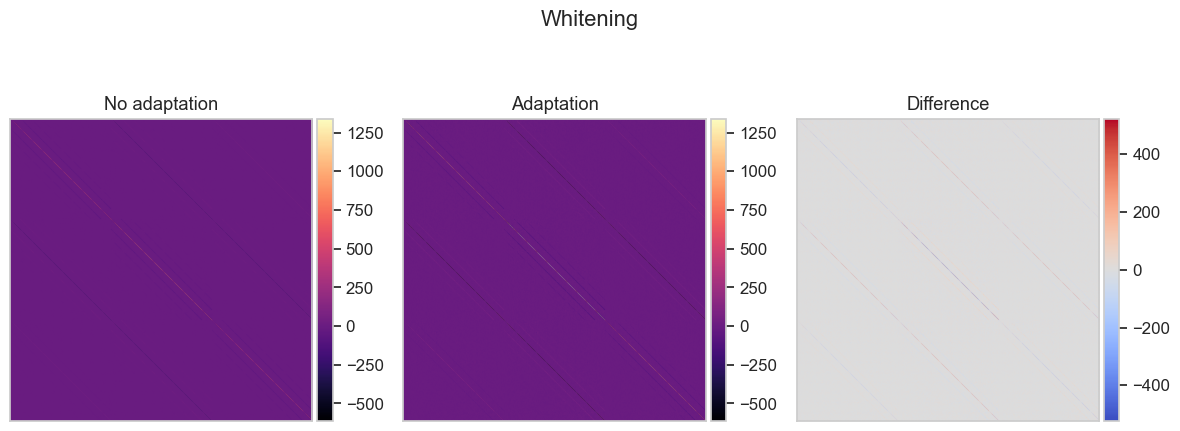

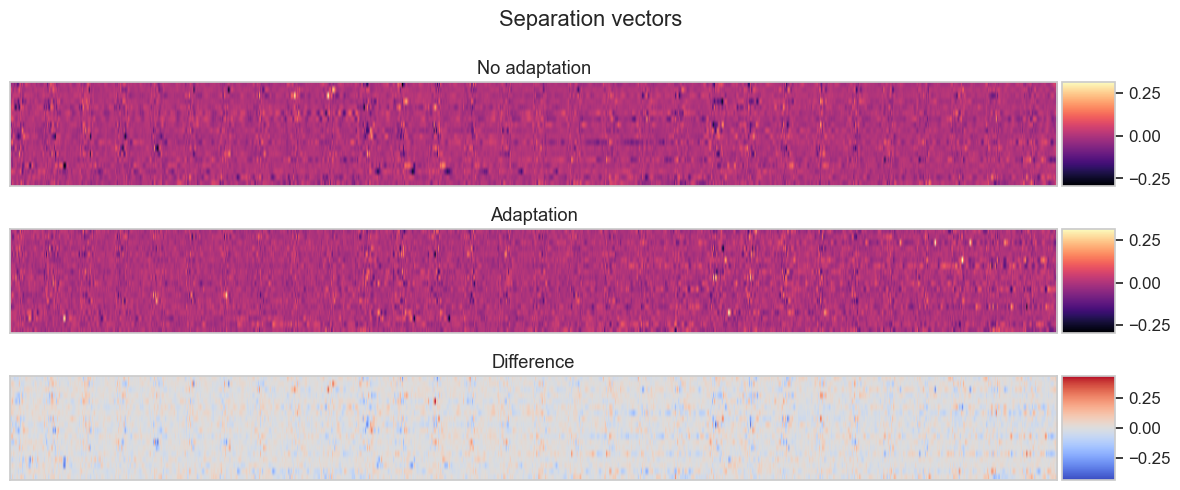

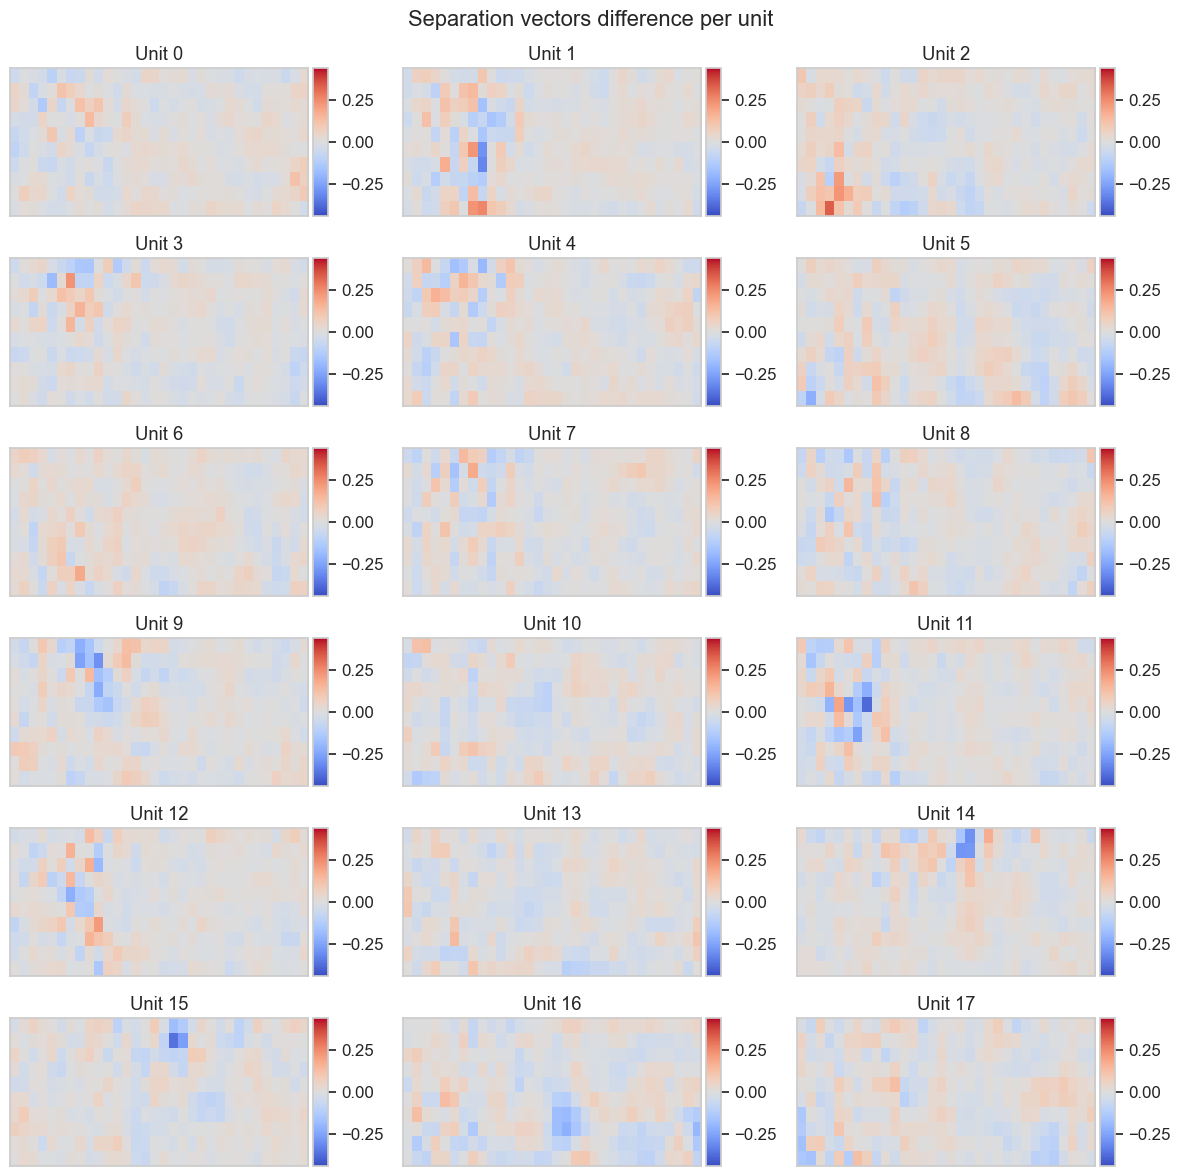

In [18]:
# cbss_result.sep_vectors is CBSSResult's own [dim, n_mu] storage convention;
# decomp.sep_vectors is [n_mu, dim] (transposed by CBSSResult.to_adapt_tensors()) --
# transpose the calibration side to compare like for like.
sep_vectors_calib = cbss_result.sep_vectors.T

ax = plot_whitening_comp(cbss_result.whitening, dyndec_adapt.decomp.whitening.cpu().numpy())
ax[0].set(title='No adaptation')
ax[1].set(title='Adaptation')
plt.suptitle('Whitening')
plt.show()

ax = plot_sep_vectors_comp(sep_vectors_calib, dyndec_adapt.decomp.sep_vectors.cpu().numpy())
ax[0].set(title='No adaptation')
ax[1].set(title='Adaptation')
plt.suptitle('Separation vectors')
plt.show()

ax = plot_sep_vectors_diff(sep_vectors_calib - dyndec_adapt.decomp.sep_vectors.cpu().numpy(), data['ch_map'])
plt.suptitle('Separation vectors difference per unit')
plt.show()